In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Churn_dataset.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.drop('customerID', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
#df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
#df = df[df["TotalCharges"].notnull()]
df['TotalCharges']=df['TotalCharges'].replace({' ':'0.0'}).astype(float)

#Exploratory Data Analysis (EDA)

##Numerical Column Analysis

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
df['SeniorCitizen'].unique()

array([0, 1])

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({1: 'Yes', 0: 'No'}).astype('object')
df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
def plot_histograms(df, cols):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')

        col_mean = df[col].mean()
        col_median = df[col].median()

        axes[i].axvline(col_mean, color='r', linestyle='--', label='Mean')
        axes[i].axvline(col_median, color='g', linestyle='-', label='Median')
        axes[i].legend()
    plt.tight_layout()
    plt.show()


def plot_boxplots(df, cols):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, col in enumerate(cols):
        axes[i].set_title(f'Distribution of {col}')
        sns.boxplot(y=df[col], ax=axes[i])
        axes[i].set_ylabel(col)
    plt.tight_layout()
    plt.show()

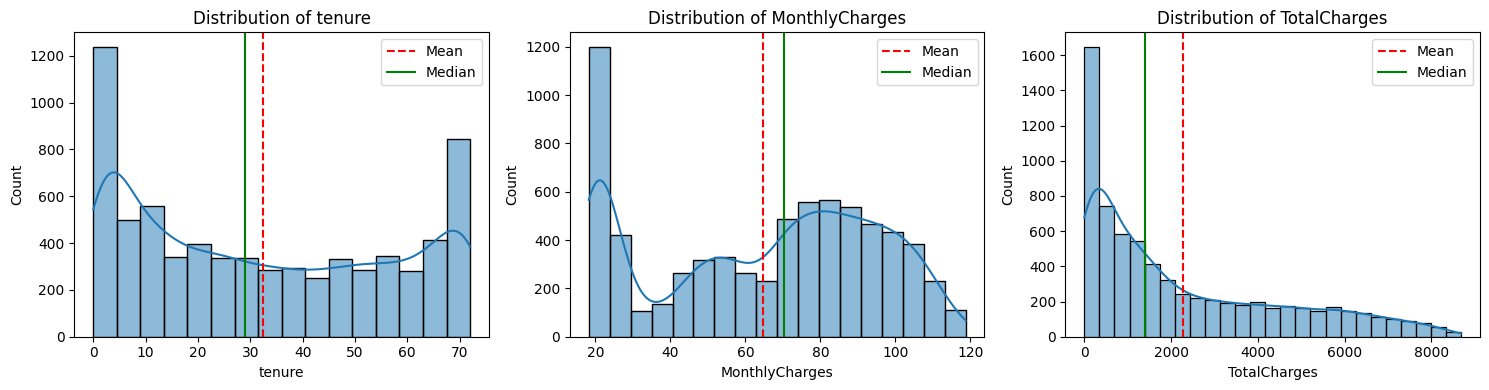

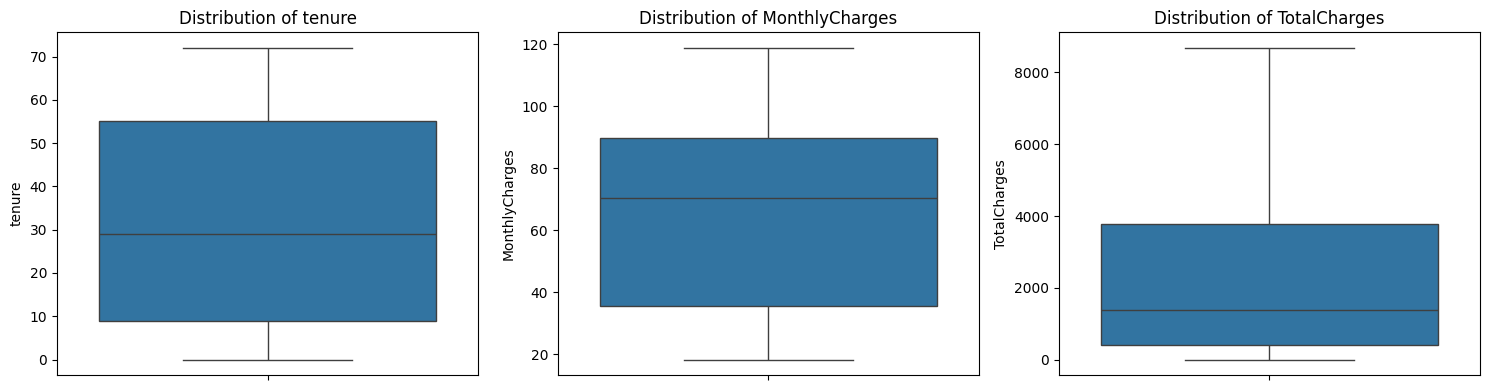

In [ ]:
plot_histograms(df, numeric_cols)
plot_boxplots(df, numeric_cols)

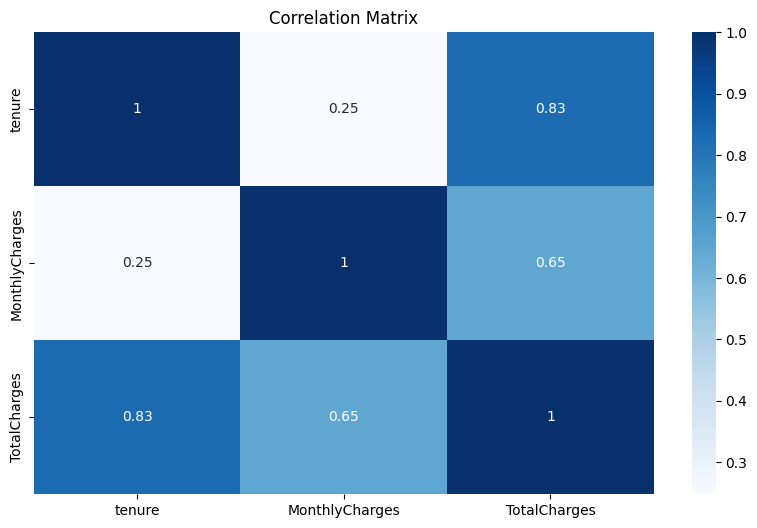

In [ ]:
plt.figure(figsize=(10, 6))
plt.title('Correlation Matrix')
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues')
plt.show()

##Categorical Column Analysis

In [ ]:
catergorical_cols = [col for col in df.columns if col not in numeric_cols and col not in ['Churn']]
catergorical_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

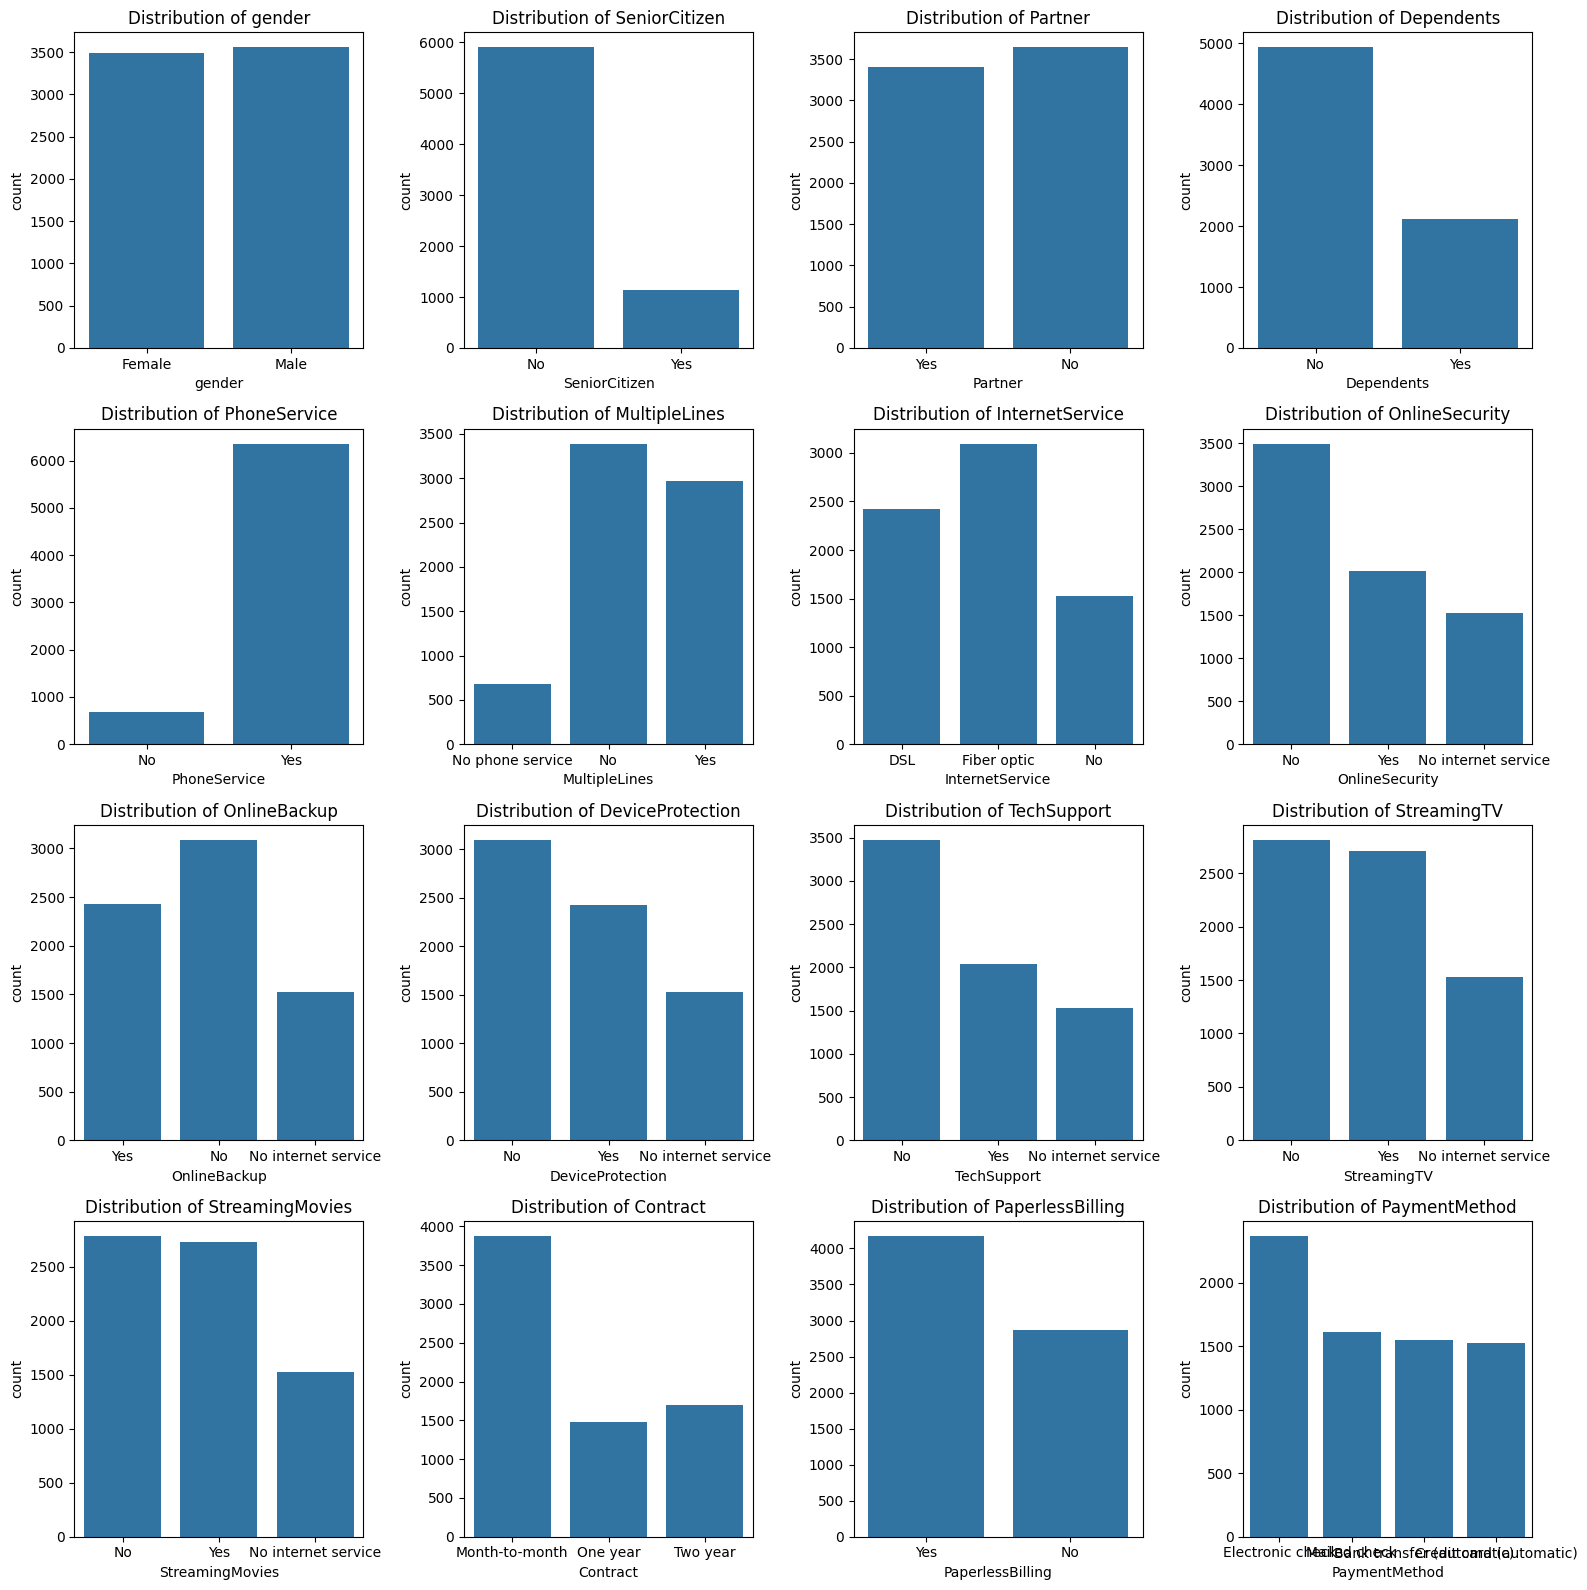

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

#df[catergorical_cols] = df[catergorical_cols].apply(lambda x: x.replace('No internet service', 'No'))
#df[catergorical_cols] = df[catergorical_cols].apply(lambda x: x.replace('No phone service', 'No'))

for i, col in enumerate(catergorical_cols):
    if i < 16:
        sns.countplot(x=col, data=df, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

In [ ]:
catergorical_cols

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

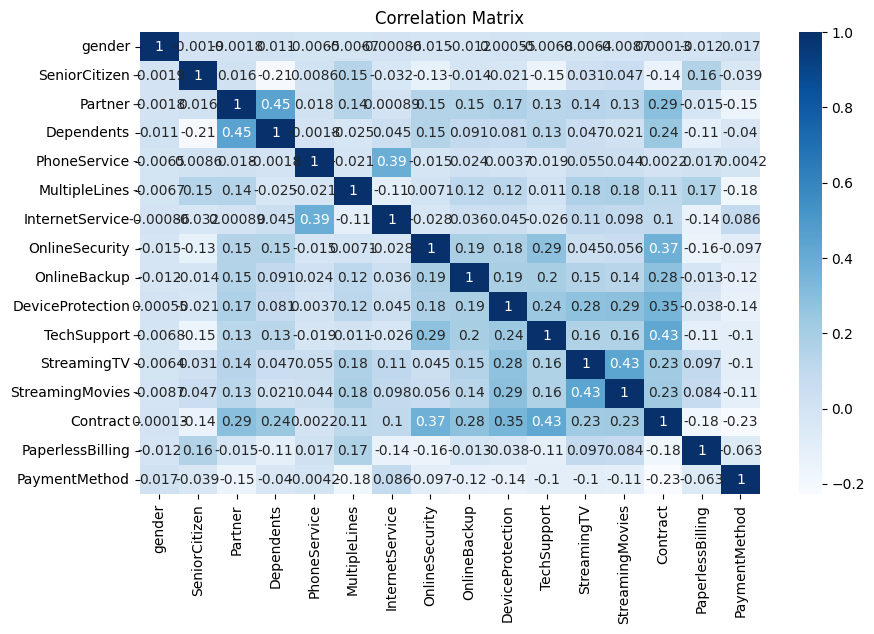

In [ ]:
from sklearn.preprocessing import LabelEncoder
import pickle

encoder = {}
for col in catergorical_cols:
  lc = LabelEncoder()
  df[col] = lc.fit_transform(df[col])
  encoder[col] = lc

plt.figure(figsize=(10, 6))
plt.title('Correlation Matrix')
sns.heatmap(df[catergorical_cols].corr(), annot=True, cmap='Blues')
plt.show()

#Model generation

##Train and test split

In [ ]:
pd.set_option('future.no_silent_downcasting', True)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0}).astype(int)
df['Churn'].unique()

array([0, 1])

In [ ]:
x = df.drop(columns=['Churn'])
y = df['Churn']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [ ]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


##Model Training

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
}

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = {}

for model_name, model in models.items():
    cv_scores[model_name] = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring='accuracy').mean()
    print(f'{model_name} CV Score: {cv_scores[model_name]:.2f}')
print()
cv_scores

Decision Tree CV Score: 0.78
Gradient Boosting CV Score: 0.82
XGBoost CV Score: 0.83
Random Forest CV Score: 0.84



{'Decision Tree': np.float64(0.7778026621130524),
 'Gradient Boosting': np.float64(0.8222685610870295),
 'XGBoost': np.float64(0.8309727512880014),
 'Random Forest': np.float64(0.8407582789672636)}

##Model Evaluation

In [ ]:
best_model = models[max(cv_scores, key=cv_scores.get)]
print(f'Best Model: {best_model}')

best_model.fit(x_train_smote, y_train_smote)
y_test_pred = best_model.predict(x_test)

Best Model: RandomForestClassifier(random_state=42)


In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_test_pred)

0.7785663591199432

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.59      0.58       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



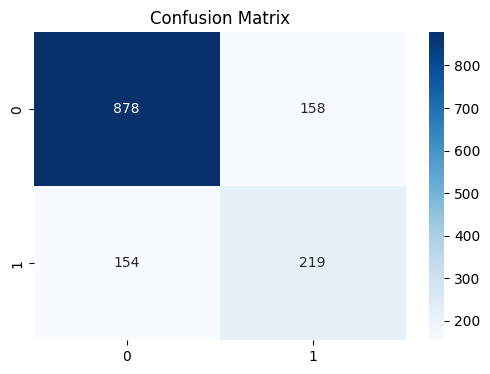

In [ ]:
plt.figure(figsize=(6,4))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.show()

In [ ]:
model_data = {
    "model": best_model,
    "encoder": encoder
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

#Load and Predict Model

In [ ]:
with open('churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

loaded_model = model["model"]
loaded_encoder = model["encoder"]

In [ ]:
loaded_encoder

{'gender': LabelEncoder(),
 'SeniorCitizen': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [ ]:
input_data = {
    "gender": "Male",
    "SeniorCitizen": "No",
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "DSL",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "MonthlyCharges": 53.85,
    "TotalCharges": 108.15
}

ip_df = pd.DataFrame([input_data])
for col, encoder in loaded_encoder.items():
  ip_df[col] = encoder.transform(ip_df[col])

In [ ]:
print("Yes") if loaded_model.predict(ip_df)[0] == 1 else print("No")
print(f'Prediction Probability: {loaded_model.predict_proba(ip_df)}')

Yes
Prediction Probability: [[0.17 0.83]]
